# Final Hyperparameter Tuning Plots

This notebook condenses the outputs from `model_final_hyperparameter_tuning.ipynb` into accessible tables and visualizations.

It reads saved result files from `results/final_model_tuning/` and compares them against the original controlled comparison outputs in `results/final_model_comparison/`.

## 1. Configuration

In [1]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

TUNING_DIR = Path("results/final_model_tuning")
COMPARISON_DIR = Path("results/final_model_comparison")
FIGURE_DIR = TUNING_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "target_next_URA"

print(f"Reading tuning results from: {TUNING_DIR.resolve()}")
print(f"Writing figures to: {FIGURE_DIR.resolve()}")

Reading tuning results from: C:\Users\Gamer2\Documents\school_sync\misc_maisteri_kurssit\case_studies_operations_research\Vayla_projekti\results\final_model_tuning
Writing figures to: C:\Users\Gamer2\Documents\school_sync\misc_maisteri_kurssit\case_studies_operations_research\Vayla_projekti\results\final_model_tuning\figures


## 2. Load Result Tables

In [2]:
TUNING_FILES = {
    "first_pass_all": "all_ura_validation_tuning_results.csv",
    "hgb_direct": "hgb_ura_validation_tuning.csv",
    "rf_sampled": "rf_ura_validation_tuning_sampled.csv",
    "hgb_delta_initial": "hgb_ura_delta_validation_tuning.csv",
    "hgb_delta_focused": "hgb_ura_delta_focused_tuning.csv",
    "hgb_delta_all": "hgb_ura_delta_all_tuning.csv",
    "direct_tuned_test": "final_ura_tuned_test_results.csv",
    "direct_tuned_breakdowns": "final_ura_tuned_test_breakdowns.csv",
}

def read_optional_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    return pd.read_csv(path)

loaded = {}
file_rows = []
for label, filename in TUNING_FILES.items():
    path = TUNING_DIR / filename
    df = read_optional_csv(path)
    if df is not None:
        loaded[label] = df
        file_rows.append({
            "label": label,
            "file": filename,
            "rows": len(df),
            "modified": pd.Timestamp(path.stat().st_mtime, unit="s"),
        })
    else:
        file_rows.append({"label": label, "file": filename, "rows": 0, "modified": pd.NaT})

file_status = pd.DataFrame(file_rows)
display(file_status.sort_values("file"))

,label,file,rows,modified
0,first_pass_all,all_ura_validation_tuning_results.csv,9,2026-04-27 18:12:42.381510258
7,direct_tuned_breakdowns,final_ura_tuned_test_breakdowns.csv,56,2026-04-27 19:14:27.953022480
6,direct_tuned_test,final_ura_tuned_test_results.csv,4,2026-04-27 19:13:50.567168951
5,hgb_delta_all,hgb_ura_delta_all_tuning.csv,21,2026-04-27 19:06:50.837151527
4,hgb_delta_focused,hgb_ura_delta_focused_tuning.csv,20,2026-04-27 19:06:50.826426268
3,hgb_delta_initial,hgb_ura_delta_validation_tuning.csv,1,2026-04-27 18:49:30.935998440
1,hgb_direct,hgb_ura_validation_tuning.csv,6,2026-04-27 18:07:19.377670288
2,rf_sampled,rf_ura_validation_tuning_sampled.csv,3,2026-04-27 18:12:42.364219189


## 3. Build Validation Leaderboard

In [3]:
validation_parts = []

for label in ["first_pass_all", "hgb_direct", "rf_sampled", "hgb_delta_initial", "hgb_delta_focused", "hgb_delta_all"]:
    df = loaded.get(label)
    if df is None:
        continue
    tmp = df.copy()
    tmp["source"] = label
    if "target_type" not in tmp.columns:
        tmp["target_type"] = "direct"
    validation_parts.append(tmp)

if not validation_parts:
    raise FileNotFoundError("No validation tuning CSVs found in results/final_model_tuning.")

validation = pd.concat(validation_parts, ignore_index=True, sort=False)
validation = validation.loc[validation["target"].eq(TARGET)].copy()
validation["params_key"] = validation["params"].fillna("").map(lambda x: json.dumps(json.loads(x), sort_keys=True) if x else "")
validation = validation.drop_duplicates(subset=["source", "model", "target", "target_type", "params_key", "rmse"])

leaderboard_cols = ["source", "model", "target_type", "candidate", "mae", "rmse", "r2", "train_rows", "evaluation_rows", "fit_seconds", "params"]
leaderboard_cols = [c for c in leaderboard_cols if c in validation.columns]
leaderboard = validation.sort_values("rmse")[leaderboard_cols]
display(leaderboard.head(20))

best = validation.sort_values("rmse").iloc[0]
print("Best validation candidate:")
print(f"  source: {best['source']}")
print(f"  model: {best['model']}")
print(f"  target_type: {best['target_type']}")
print(f"  rmse: {best['rmse']:.4f}")
print(f"  mae: {best['mae']:.4f}")
print(f"  r2: {best['r2']:.4f}")
print(f"  params: {best['params']}")

,source,model,target_type,candidate,mae,rmse,r2,train_rows,evaluation_rows,fit_seconds,params
19,hgb_delta_focused,hist_gradient_boosting,delta_converted_to_actual,18.0,1.056438,1.645404,0.861152,2683410,574718,51.376046,"{""learning_rate"": 0.1, ""max_iter"": 400, ""max_l..."
39,hgb_delta_all,hist_gradient_boosting,delta_converted_to_actual,18.0,1.056438,1.645404,0.861152,2683410,574718,51.376046,"{""learning_rate"": 0.1, ""max_iter"": 400, ""max_l..."
40,hgb_delta_all,hist_gradient_boosting,delta_converted_to_actual,10.0,1.062200,1.649290,0.860495,2683410,574718,46.152275,"{""learning_rate"": 0.1, ""max_iter"": 350, ""max_l..."
20,hgb_delta_focused,hist_gradient_boosting,delta_converted_to_actual,10.0,1.062200,1.649290,0.860495,2683410,574718,46.152275,"{""learning_rate"": 0.1, ""max_iter"": 350, ""max_l..."
21,hgb_delta_focused,hist_gradient_boosting,delta_converted_to_actual,19.0,1.069874,1.660783,0.858544,2683410,574718,72.813696,"{""learning_rate"": 0.06, ""max_iter"": 650, ""max_..."
41,hgb_delta_all,hist_gradient_boosting,delta_converted_to_actual,19.0,1.069874,1.660783,0.858544,2683410,574718,72.813696,"{""learning_rate"": 0.06, ""max_iter"": 650, ""max_..."
42,hgb_delta_all,hist_gradient_boosting,delta_converted_to_actual,17.0,1.068760,1.661052,0.858498,2683410,574718,49.772665,"{""learning_rate"": 0.1, ""max_iter"": 400, ""max_l..."
22,hgb_delta_focused,hist_gradient_boosting,delta_converted_to_actual,17.0,1.068760,1.661052,0.858498,2683410,574718,49.772665,"{""learning_rate"": 0.1, ""max_iter"": 400, ""max_l..."
23,hgb_delta_focused,hist_gradient_boosting,delta_converted_to_actual,8.0,1.073049,1.662577,0.858238,2683410,574718,48.879364,"{""learning_rate"": 0.08, ""max_iter"": 350, ""max_..."
43,hgb_delta_all,hist_gradient_boosting,delta_converted_to_actual,8.0,1.073049,1.662577,0.858238,2683410,574718,48.879364,"{""learning_rate"": 0.08, ""max_iter"": 350, ""max_..."


Best validation candidate:
  source: hgb_delta_focused
  model: hist_gradient_boosting
  target_type: delta_converted_to_actual
  rmse: 1.6454
  mae: 1.0564
  r2: 0.8612
  params: {"learning_rate": 0.1, "max_iter": 400, "max_leaf_nodes": 127, "min_samples_leaf": 150, "l2_regularization": 0.1}


## 4. Search Progression Summary

,stage,rmse,mae,r2
4,focused HGB delta,1.645404,1.056438,0.861152
3,initial HGB delta,1.702315,1.104680,0.851381
1,first-pass HGB direct,1.713000,1.110296,0.849509
2,first-pass RF sampled,1.735563,1.105167,0.845518
0,comparison HGB direct,1.763580,1.148788,0.840491


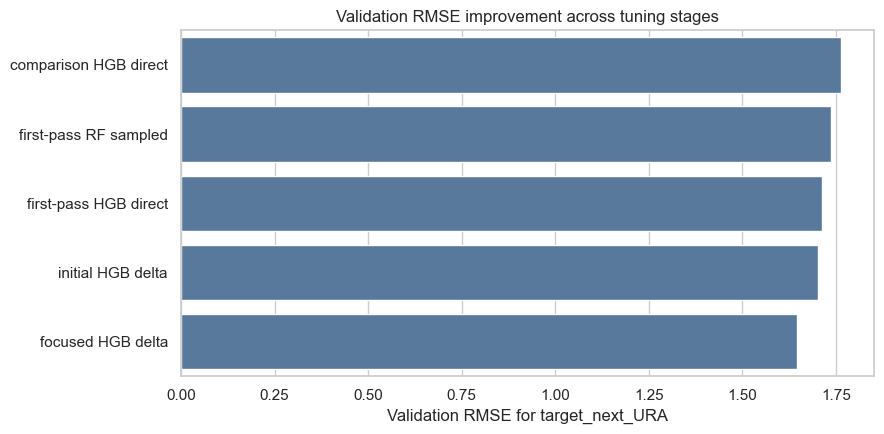

In [4]:
comparison_validation_path = COMPARISON_DIR / "validation_results.csv"
comparison_test_path = COMPARISON_DIR / "test_results_overall.csv"

stage_rows = []
comparison_validation = read_optional_csv(comparison_validation_path)
if comparison_validation is not None:
    base = comparison_validation.loc[
        comparison_validation["target"].eq(TARGET)
        & comparison_validation["model"].eq("hist_gradient_boosting")
        & comparison_validation["feature_mixture"].eq("current_static_lag_lifecycle_material")
    ].sort_values("rmse")
    if len(base):
        row = base.iloc[0]
        stage_rows.append({"stage": "comparison HGB direct", "rmse": row["rmse"], "mae": row["mae"], "r2": row["r2"]})

def add_best_stage(stage: str, mask):
    subset = validation.loc[mask].sort_values("rmse")
    if len(subset):
        row = subset.iloc[0]
        stage_rows.append({"stage": stage, "rmse": row["rmse"], "mae": row["mae"], "r2": row["r2"]})

add_best_stage("first-pass HGB direct", validation["source"].isin(["first_pass_all", "hgb_direct"]) & validation["model"].eq("hist_gradient_boosting") & validation["target_type"].eq("direct"))
add_best_stage("first-pass RF sampled", validation["source"].isin(["first_pass_all", "rf_sampled"]) & validation["model"].eq("random_forest"))
add_best_stage("initial HGB delta", validation["source"].eq("hgb_delta_initial"))
add_best_stage("focused HGB delta", validation["source"].isin(["hgb_delta_focused", "hgb_delta_all"]))

stage_summary = pd.DataFrame(stage_rows).drop_duplicates(subset=["stage"]).sort_values("rmse")
display(stage_summary)

plt.figure(figsize=(9, 4.5))
plot_df = stage_summary.sort_values("rmse", ascending=False)
sns.barplot(data=plot_df, y="stage", x="rmse", color="#4C78A8")
plt.title("Validation RMSE improvement across tuning stages")
plt.xlabel("Validation RMSE for target_next_URA")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "validation_rmse_by_tuning_stage.png", dpi=160)
plt.show()

## 5. Candidate Leaderboard Plot

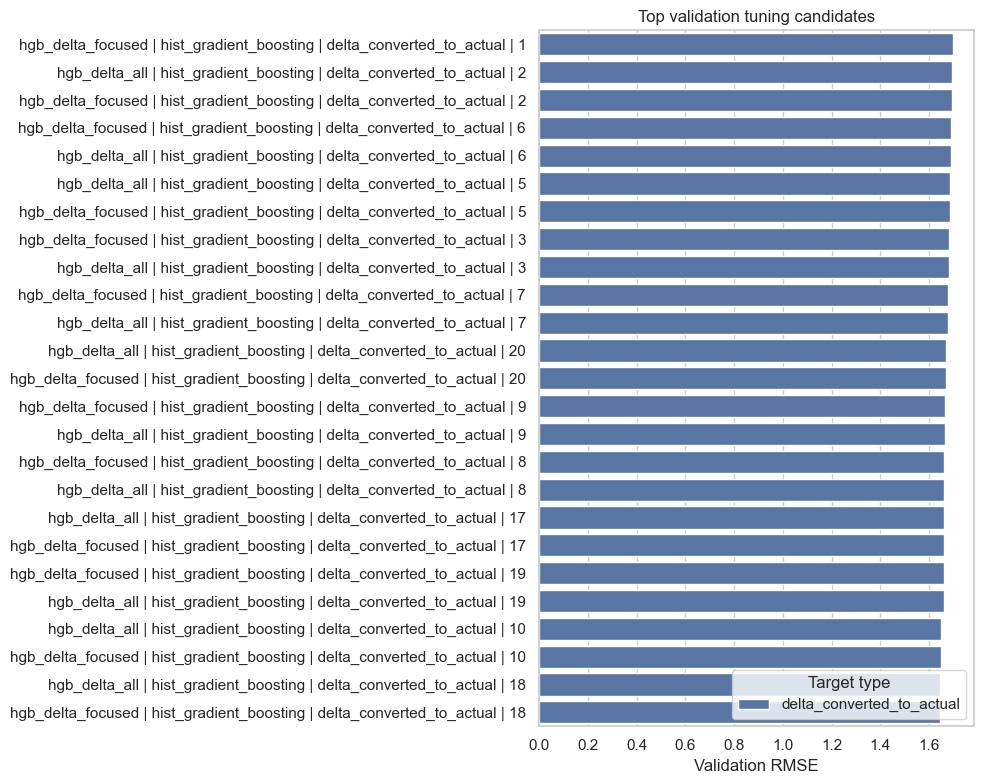

In [5]:
plot_candidates = validation.sort_values("rmse").head(25).copy()
plot_candidates["label"] = plot_candidates.apply(
    lambda r: f"{r['source']} | {r['model']} | {r['target_type']} | {int(r['candidate']) if pd.notna(r.get('candidate', np.nan)) else '-'}",
    axis=1,
)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_candidates.sort_values("rmse", ascending=False), y="label", x="rmse", hue="target_type", dodge=False)
plt.title("Top validation tuning candidates")
plt.xlabel("Validation RMSE")
plt.ylabel("")
plt.legend(title="Target type", loc="lower right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_validation_tuning_candidates.png", dpi=160)
plt.show()

## 6. Focused HGB Delta Parameter Effects

,model,target,target_type,candidate,train_rows,evaluation_rows,fit_seconds,mae,rmse,r2,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization
0,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,18,2683410,574718,51.376046,1.056438,1.645404,0.861152,0.10,400,127,150,0.10
1,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,10,2683410,574718,46.152275,1.062200,1.649290,0.860495,0.10,350,127,100,0.05
2,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,19,2683410,574718,72.813696,1.069874,1.660783,0.858544,0.06,650,95,150,0.10
3,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,17,2683410,574718,49.772665,1.068760,1.661052,0.858498,0.10,400,95,150,0.10
4,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,8,2683410,574718,48.879364,1.073049,1.662577,0.858238,0.08,350,127,100,0.05
5,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,9,2683410,574718,44.827987,1.075491,1.666525,0.857564,0.10,350,95,100,0.05
6,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,20,2683410,574718,39.134411,1.075782,1.668061,0.857301,0.12,300,95,150,0.10
7,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,7,2683410,574718,45.145880,1.086370,1.679845,0.855278,0.08,350,95,100,0.05
8,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,3,2683410,574718,53.646091,1.089145,1.683035,0.854728,0.08,500,63,100,0.05
9,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,5,2683410,574718,44.840221,1.089515,1.684655,0.854448,0.10,400,63,100,0.05


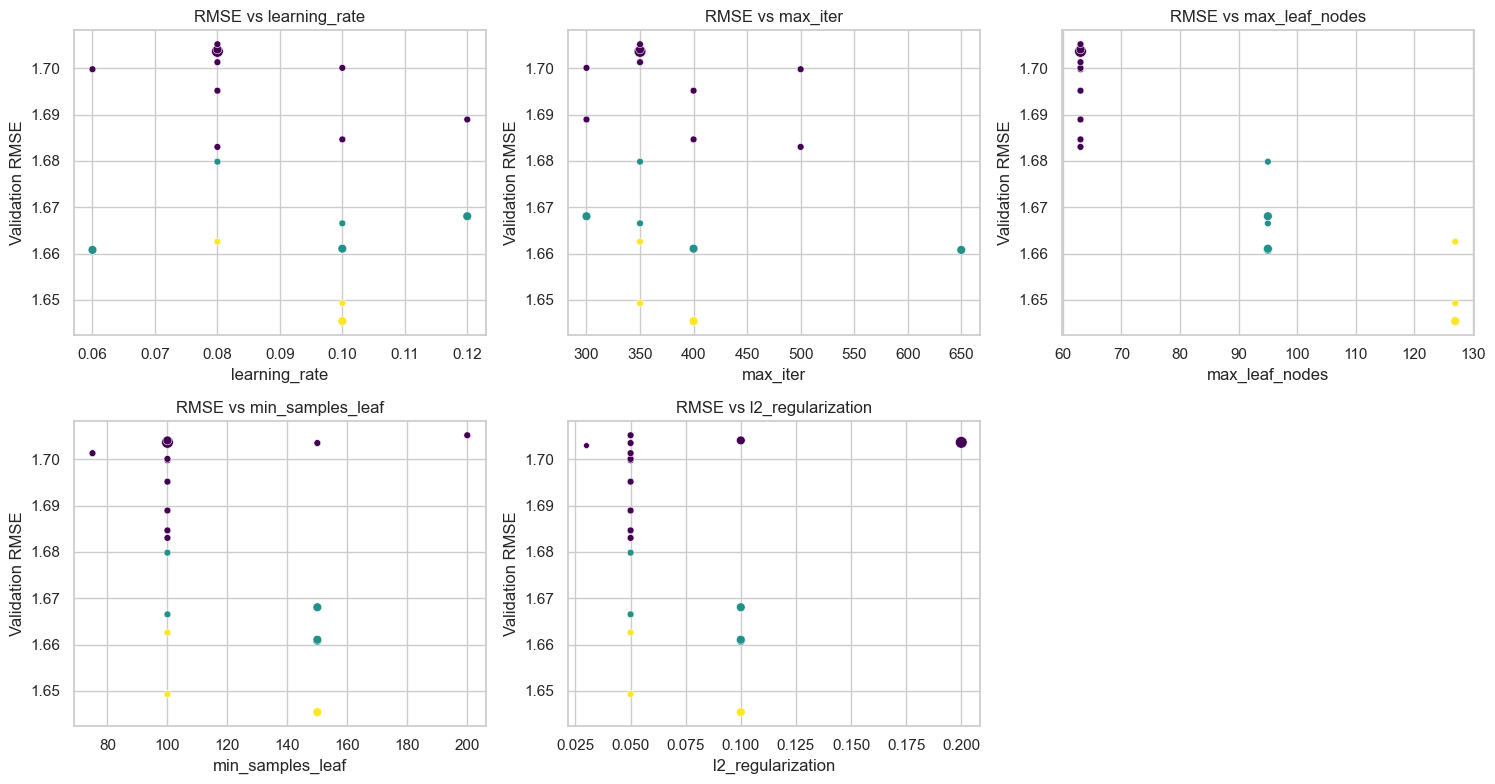

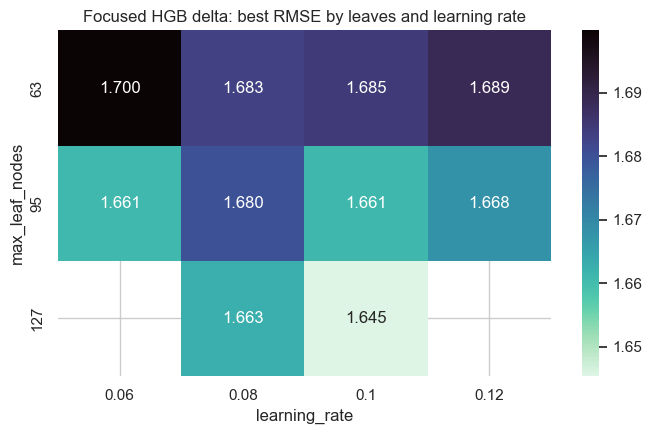

In [6]:
focused = loaded.get("hgb_delta_focused")
if focused is None:
    print("Focused HGB delta tuning file not found. Run section 10 of model_final_hyperparameter_tuning.ipynb first.")
else:
    focused = focused.copy()
    param_df = pd.json_normalize(focused["params"].map(json.loads))
    focused_params = pd.concat([focused.drop(columns=["params"]), param_df], axis=1).sort_values("rmse")
    display(focused_params.head(20))

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    param_cols = ["learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]
    for ax, col in zip(axes.flat, param_cols):
        sns.scatterplot(data=focused_params, x=col, y="rmse", hue="max_leaf_nodes", size="l2_regularization", palette="viridis", ax=ax, legend=False)
        ax.set_title(f"RMSE vs {col}")
        ax.set_ylabel("Validation RMSE")
    axes.flat[-1].axis("off")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "focused_hgb_delta_parameter_effects.png", dpi=160)
    plt.show()

    pivot = focused_params.pivot_table(index="max_leaf_nodes", columns="learning_rate", values="rmse", aggfunc="min")
    plt.figure(figsize=(7, 4.5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="mako_r")
    plt.title("Focused HGB delta: best RMSE by leaves and learning rate")
    plt.xlabel("learning_rate")
    plt.ylabel("max_leaf_nodes")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "focused_hgb_delta_leaf_lr_heatmap.png", dpi=160)
    plt.show()

## 7. Test Context For Direct Tuned Models

The final test result for the focused delta winner should come from `model_final_training.ipynb`, because that notebook selects the best validation candidate and evaluates it once on the untouched test split. The table below is included only to contextualize the earlier direct tuned-model test check.

,source,model,target,target_type,target_role,feature_mixture,train_rows,evaluation_rows,mae,rmse,r2,params
6,direct_tuned_test_check,hist_gradient_boosting,target_next_URA,direct,tuned_primary,current_static_lag_lifecycle_material,3258128,575195,1.112824,1.716192,0.849478,"{""learning_rate"": 0.08, ""max_iter"": 350, ""max_..."
7,direct_tuned_test_check,random_forest,target_next_URA,direct,tuned_primary,current_static_lag_lifecycle_material,600000,575195,1.107865,1.737325,0.845749,"{""n_estimators"": 350, ""max_features"": ""sqrt"", ..."
0,model_comparison_final,hist_gradient_boosting,target_next_URA,direct,NaN,current_static_lag_lifecycle_material,3258128,575195,1.150635,1.765230,0.840754,NaN
1,model_comparison_final,random_forest,target_next_URA,direct,NaN,current_static_lag_lifecycle_material,300000,575195,1.141090,1.774198,0.839131,NaN
2,model_comparison_final,gradient_boosting,target_next_URA,direct,NaN,current_static_lag_lifecycle_material,150000,575195,1.209294,1.841161,0.826759,NaN
3,model_comparison_final,linear_regression,target_next_URA,direct,NaN,current_static_lag_lifecycle_material,3258128,575195,1.286372,1.923522,0.810913,NaN
4,model_comparison_final,ridge,target_next_URA,direct,NaN,current_static_lag_lifecycle_material,3258128,575195,1.286372,1.923522,0.810913,NaN
5,model_comparison_final,persistence,target_next_URA,direct,NaN,persistence,3258128,575195,1.894494,2.645991,0.642197,NaN


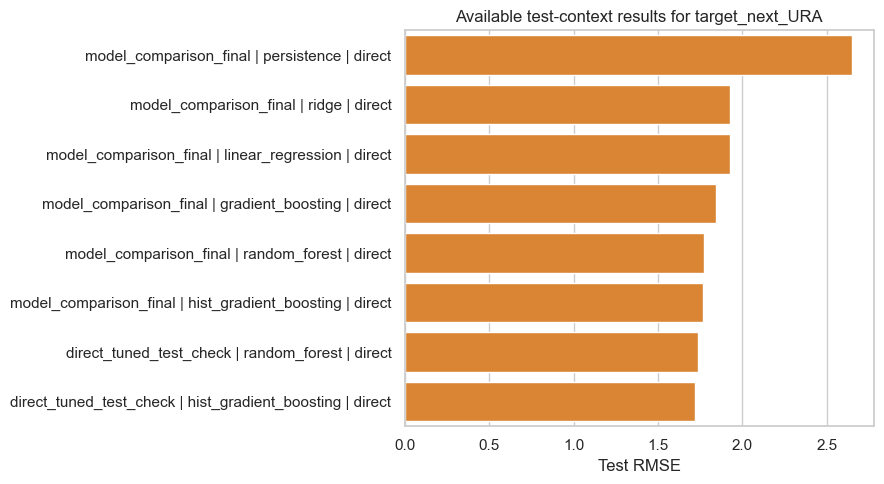

In [7]:
test_parts = []

comparison_test = read_optional_csv(comparison_test_path)
if comparison_test is not None:
    tmp = comparison_test.loc[comparison_test["target"].eq(TARGET)].copy()
    tmp["source"] = "model_comparison_final"
    test_parts.append(tmp)

direct_tuned_test = loaded.get("direct_tuned_test")
if direct_tuned_test is not None:
    tmp = direct_tuned_test.loc[direct_tuned_test["target"].eq(TARGET)].copy()
    tmp["source"] = "direct_tuned_test_check"
    if "feature_mixture" not in tmp.columns:
        tmp["feature_mixture"] = "current_static_lag_lifecycle_material"
    test_parts.append(tmp)

if test_parts:
    test_context = pd.concat(test_parts, ignore_index=True, sort=False).sort_values("rmse")
    display(test_context[[c for c in ["source", "model", "target", "target_type", "target_role", "feature_mixture", "train_rows", "evaluation_rows", "mae", "rmse", "r2", "params"] if c in test_context.columns]])

    plot_test = test_context.head(12).copy()
    plot_test["label"] = plot_test["source"] + " | " + plot_test["model"].astype(str) + " | " + plot_test["target_type"].fillna("direct")
    plt.figure(figsize=(9, 5))
    sns.barplot(data=plot_test.sort_values("rmse", ascending=False), y="label", x="rmse", color="#F58518")
    plt.title("Available test-context results for target_next_URA")
    plt.xlabel("Test RMSE")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "available_test_context_ura.png", dpi=160)
    plt.show()
else:
    print("No test-context CSVs found.")

## 8. Final Recommendation Printout

In [8]:
best = validation.sort_values("rmse").iloc[0]
best_params = json.loads(best["params"])

print("Recommended next step")
print("---------------------")
print("Move to model_final_training.ipynb and run it from the top.")
print("That notebook will select the best validation candidate, train on train + validation, and evaluate once on test.")
print()
print("Selected validation candidate")
print(f"model: {best['model']}")
print(f"target: {best['target']}")
print(f"target_type: {best['target_type']}")
print(f"validation RMSE: {best['rmse']:.4f}")
print(f"validation MAE: {best['mae']:.4f}")
print(f"validation R2: {best['r2']:.4f}")
print("params:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

Recommended next step
---------------------
Move to model_final_training.ipynb and run it from the top.
That notebook will select the best validation candidate, train on train + validation, and evaluate once on test.

Selected validation candidate
model: hist_gradient_boosting
target: target_next_URA
target_type: delta_converted_to_actual
validation RMSE: 1.6454
validation MAE: 1.0564
validation R2: 0.8612
params:
  learning_rate: 0.1
  max_iter: 400
  max_leaf_nodes: 127
  min_samples_leaf: 150
  l2_regularization: 0.1
